# Preprocessing Pipeline
## Predicting Customer Lifetime Value to Optimize Value-Based Bidding and Paid Advertising Budget Allocation

**Student:** Christian Alan Vibar\
**Course:** MAB2134 Analytics Algorithms 1 (Predictive Analytics 1)  
**Term:** 3rd / SY 2025–2026  
**Instructor:** Francis Adrian Viernes, CFA, MBA, MSF, CCREP, PMDSA

---

### Purpose of this Notebook
This notebook covers the Data Preparation phase of CRISP-DM for the project. It implements all cleaning, feature engineering, and preprocessing steps deferred from `01_eda.ipynb`. Steps that involve learned parameters (imputation medians, OHE category vocabularies, scaler statistics) are fitted exclusively on the training set and applied to both train and test. This notebook produces the analytical dataset consumed by `03_modeling.ipynb`.

---

### Business Context

**Business problem:** The current CLV model relies on manually-maintained retention curves with a shifting denominator, making customer value estimates unreliable for cross-channel and cross-segment comparison. This leads to the risk of chronic budget misallocation toward lower-value segments and undermines the effectiveness of value-based bidding (VBB) — an algorithmic bidding strategy that requires accurate customer value signals to optimize bids on ad platform auctions.

**Stakeholder:** Marketing team responsible for paid advertising strategy and budget planning.

**Decision / action:** Allocate paid advertising budget toward acquisition channels and segments that predict higher 12-month customer lifetime value. Model outputs also serve as the customer value signal for VBB on paid ad platform auctions.

**Unit of analysis:** One customer (one row = one customer record).

**Target:** `revenue_first_12_months` — total gross revenue in the first 12 months of the customer's lifetime, in absolute dollars.

**Prediction horizon:** At or near customer acquisition — before any retention, upsell, or account management action is taken.

---

### Preprocessing Decisions Summary
All decisions below were established through EDA findings in `01_eda.ipynb` and confirmed prior to implementation.

| Step | Decision | Justification |
|---|---|---|
| Scope filter | `broader_source == 'paid_inbound'` only | Modeling population is paid acquisition channels only |
| Outlier removal | Drop row where `starting_mrr > 90000` | `$93,571` MRR with anomalously low revenue (`$21,968`); likely data error (EDA Section 3.3.1) |
| `ad_network` fix | Derive 4 `-` values from `channel` field | Attribution tracking gap; `channel` confirms platform |
| `cb_employees_range` fix | Replace Excel date artifacts (`01-Oct` → `1-10`, `Nov-50` → `11-50`) | Auto-formatting corruption on CSV export (EDA Section 1.2) |
| `starting_mrr` missingness | Median imputation (train only) | 6.7% missing; median preferred over mean given right skew |
| Categorical nulls | Fill with `'missing'` category | Missingness may carry signal; retains information rather than discarding rows |
| Low-frequency categories | Collapse to `'other'` using train-set thresholds | Reduces OHE sparsity; prevents unseen-category issues at deployment |
| Encoding | One-hot encoding with `drop='first'` | Avoids multicollinearity for Ridge; tree models are unaffected |
| Scaling | `StandardScaler` on numeric features (train only) | Required for Ridge regression; separate unscaled version kept for tree models |

## 0. Preliminaries

In [1]:
# BASIC PACKAGES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# SKLEARN
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# REPRODUCIBILITY
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# DISPLAY OPTIONS
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_rows', 100)

# AESTHETICS
sns.set_style('whitegrid')
plt.style.use('seaborn-v0_8-whitegrid')

print('Packages loaded successfully.')

Packages loaded successfully.


## 1. Data Loading & Cleaning

All steps in this section are parameter-free and applied to the full dataset before the train/test split. No learned statistics are computed here.

### 1.1 Load Raw Data

In [2]:
df = pd.read_csv('../data/mab2134_data_raw.csv')
print(f'Raw dataset shape: {df.shape}')
df.head(3)

Raw dataset shape: (1273, 48)


,client_id,hubspot_client_id,lifecycle,channel,broader_source,broad_source,service_offering,campaign_group,campaign,ad_group,ad,ad_network,creative_group,creative_variation,keyword_text,keyword_match_type,placement,facebook_ad_set_audience,client_country,client_location_state,client_local_timezone,cb_city,email_type,email_industry_type,cb_jobtitle_type,cb_employees_range,cb_annual_revenue_ranges,cb_industry,cb_sector,cb_industry_group,cb_sub_industry,attributed_at,attributed_date,signup_at,signup_date,customer_date,first_billing_week,last_billing_week,revenue_first_1_month,revenue_first_2_months,revenue_first_3_months,revenue_first_6_months,total_revenue,starting_mrr,latest_mrr,profit,active_weeks,revenue_first_12_months
0,680247841beb878e1a8ff164f7296de7_1,96349503.0000,1,import,offline,offline,NaN,no_campaign_group,-,-,-,-,non_facebook_ad,non_facebook_ad,NaN,NaN,NaN,not_facebook,united states,unknown,America/New_York,norwalk,paid_email,NaN,senior leadership,Nov-50,$1M-$10M,Renewable Electricity,Utilities,Independent Power and Renewable Electricity Pr...,Renewable Energy,2023-09-19T19:52:22.747000,19/09/2023,2023-09-21T06:19:23.375000,21/09/2023,11/11/2023,11/11/2023,31/05/2025,4641.4286,7092.8571,9458.5714,17209.2857,38415.0000,649.5000,649.5000,12805.0000,79,31605.0000
1,79448c4c120cc3750709546d6ae90974_2,17680601.0000,2,duckduckgo,organic_inbound,organic_search,executive_assistant,no_campaign_group,-,-,-,-,non_facebook_ad,non_facebook_ad,appointment setting services,BROAD,NaN,not_facebook,united states,tennessee,America/New_York,chattanooga,paid_email,NaN,senior leadership,01-Oct,$0-$1M,Diversified Consumer Services,Consumer Discretionary,Consumer Services,Specialized Consumer Services,2023-10-19T07:33:47.875000,19/10/2023,2023-10-19T07:32:32.602000,19/10/2023,28/10/2023,28/10/2023,26/07/2025,814.2857,2147.1429,3501.4286,7358.5714,29535.0000,1299.0000,1299.0000,13660.0000,78,20764.2857
2,c07f9ec7fc78d410859d0b28fd84e676_1,98397401.0000,1,youtube,organic_inbound,social_media,executive_assistant,no_campaign_group,-,-,-,-,non_facebook_ad,non_facebook_ad,NaN,NaN,NaN,not_facebook,united states,colorado,America/Denver,austin,paid_email,NaN,senior leadership,01-Oct,$0-$1M,Professional Services,Industrials,Commercial & Professional Services,Human Resource & Employment Services,2023-10-05T15:58:17.255000,05/10/2023,2023-10-05T15:58:02.697000,05/10/2023,28/10/2023,28/10/2023,31/01/2026,2588.5714,5005.7143,7662.8571,14897.1429,69840.0000,2598.0000,2598.0000,32032.0000,118,30668.5714


### 1.2 Column Value Cleanup: `cb_employees_range` Excel Artifact

Replicated from EDA Section 1.2. The values `1-10` and `11-50` were corrupted to `01-Oct` and `Nov-50` by Excel's auto-formatting during CSV export. Corrected before any downstream processing.

In [3]:
print('Before fix:')
print(df['cb_employees_range'].value_counts(dropna=False))

df['cb_employees_range'] = df['cb_employees_range'].replace({
    '01-Oct': '1-10',
    'Nov-50': '11-50'
})

print('\nAfter fix:')
print(df['cb_employees_range'].value_counts(dropna=False))

Before fix:
cb_employees_range
01-Oct      431
NaN         335
Nov-50      319
51-250      119
251-1K       41
1K-5K        13
10K-50K       5
5K-10K        4
50K-100K      4
100K+         1
51-200        1
Name: count, dtype: int64

After fix:
cb_employees_range
1-10        431
NaN         335
11-50       319
51-250      119
251-1K       41
1K-5K        13
10K-50K       5
5K-10K        4
50K-100K      4
100K+         1
51-200        1
Name: count, dtype: int64


### 1.3 Scope Filter: Paid Inbound Only

The modeling population is restricted to paid inbound customers. That is, customers acquired through a paid advertising channel. This matches the population used in the EDA (`broader_source == 'paid_inbound'`). All other acquisition channels (organic, outbound, offline, email) are excluded as they are not relevant to the value-based bidding use case.

In [4]:
df = df[df['broader_source'] == 'paid_inbound'].copy()
print(f'Shape after paid inbound filter: {df.shape}')
print(f'Expected: (535, 48)')

Shape after paid inbound filter: (535, 48)
Expected: (535, 48)


### 1.4 Drop Outlier Row

One record with `starting_mrr = $93,571` shows anomalously low `revenue_first_12_months` ($21,968) relative to its plan size. This is a revenue-to-MRR ratio far below all comparable records. This was flagged in EDA Section 3.3.1 as a likely data error. It is dropped before modeling to prevent distortion of learned splits at the top of the MRR range.

Row 128 (`starting_mrr = $42,261`, `revenue_first_12_months = $205,212`) is a legitimate high-retention account and is retained.

In [5]:
print('Outlier record:')
print(df[df['starting_mrr'] > 90000][['starting_mrr', 'revenue_first_12_months']])

df = df[(df['starting_mrr'].isnull()) | (df['starting_mrr'] <= 90000)].copy()
print(f'\nShape after outlier drop: {df.shape}')
print(f'Expected: (534, 48)')

Outlier record:
     starting_mrr  revenue_first_12_months
423    93571.3000               21967.5572

Shape after outlier drop: (534, 48)
Expected: (534, 48)


### 1.5 Resolve `ad_network` Attribution Gaps

Four paid inbound records have `ad_network = '-'`, indicating a tracking gap where the ad network field failed to populate. The `channel` field reliably identifies the platform for these records (3 × `facebook`, 1 × `adwords`). Values are corrected by deriving directly from other fields; no imputation model is needed.

In [6]:
print('Before fix:')
print(df['ad_network'].value_counts(dropna=False))

mask = df['ad_network'] == '-'
df.loc[mask, 'ad_network'] = df.loc[mask, 'channel'].map({
    'facebook': 'facebook',
    'adwords': 'adwords'
})

print('\nAfter fix:')
print(df['ad_network'].value_counts(dropna=False))
print(f'\nRemaining unresolved: {(df["ad_network"] == "-").sum()}')

Before fix:
ad_network
adwords     341
facebook    171
bing         11
linkedin      5
-             4
twitter       2
Name: count, dtype: int64

After fix:
ad_network
adwords     342
facebook    174
bing         11
linkedin      5
twitter       2
Name: count, dtype: int64

Remaining unresolved: 0


### 1.6 Drop Excluded Columns

Columns excluded from the modeling feature set, as established in EDA Section 3.4–3.6:

- **ID fields**: `client_id`, `hubspot_client_id`
- **Timestamp fields**: `attributed_at`, `attributed_date`, `signup_at`, `signup_date`, `customer_date`, `first_billing_week`, `last_billing_week`
- **Scope field** (used for filtering only): `broader_source`
- **Revenue intermediates** (target leakage): `revenue_first_1_month`, `revenue_first_2_months`, `revenue_first_3_months`, `revenue_first_6_months`, `total_revenue`
- **Post-acquisition metrics** (target leakage): `latest_mrr`, `profit`, `active_weeks`
- **High-missingness attribution fields** (signal already captured by `channel` and `ad_network`): `placement`, `email_industry_type`, `keyword_match_type`, `keyword_text`
- **Granular campaign fields** (too high cardinality, signal captured by `campaign_group`): `campaign`, `ad_group`, `ad`, `creative_group`, `creative_variation`
- **Redundant geographic fields**: `cb_city`, `client_location_state`, `client_local_timezone`
- **Redundant industry fields** (signal captured by `cb_sector`): `cb_industry`, `cb_industry_group`, `cb_sub_industry`
- **Other redundant attribution fields**: `broad_source`, `channel`, `ad`, `facebook_ad_set_audience`, `email_type`
- **Geographic signal insufficient**: `client_country` — 85.0% US, 7.5% Canada; near-binary distribution with a 14-country noisy tail. The feature reduces to an effective binary split with insufficient signal to justify the additional OHE columns.

In [7]:
DROP_COLS = [
    # Identifiers
    'client_id', 'hubspot_client_id',
    # Timestamps
    'attributed_at', 'attributed_date', 'signup_at', 'signup_date',
    'customer_date', 'first_billing_week', 'last_billing_week',
    # Scope field
    'broader_source',
    # Revenue intermediates (leakage)
    'revenue_first_1_month', 'revenue_first_2_months',
    'revenue_first_3_months', 'revenue_first_6_months',
    'total_revenue',
    # Post-acquisition metrics (leakage)
    'latest_mrr', 'profit', 'active_weeks',
    # High-missingness attribution fields
    'placement', 'email_industry_type', 'keyword_match_type', 'keyword_text',
    # Granular campaign fields
    'campaign', 'ad_group', 'ad', 'creative_group', 'creative_variation',
    # Redundant geographic fields
    'cb_city', 'client_location_state', 'client_local_timezone',
    # Redundant industry fields
    'cb_industry', 'cb_industry_group', 'cb_sub_industry',
    # Redundant attribution fields
    'broad_source', 'channel', 'facebook_ad_set_audience', 'email_type',
    # Geographic concentration too high to be useful
    'client_country',  # 85% US, 7.5% Canada — near-binary with noisy tail; insufficient signal to justify OHE columns
]

# Only drop columns that are actually present
drop_present = [c for c in DROP_COLS if c in df.columns]
df = df.drop(columns=drop_present)

print(f'Shape after column drops: {df.shape}')
print(f'\nRemaining columns:')
print(df.columns.tolist())

Shape after column drops: (534, 10)

Remaining columns:
['lifecycle', 'service_offering', 'campaign_group', 'ad_network', 'cb_jobtitle_type', 'cb_employees_range', 'cb_annual_revenue_ranges', 'cb_sector', 'starting_mrr', 'revenue_first_12_months']


### 1.7 Cleaned Dataset Snapshot

In [8]:
print(f'Final cleaned shape: {df.shape}')
print('\n--- dtypes ---')
print(df.dtypes)
print('\n--- missingness ---')
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(1)
missing_summary = pd.DataFrame({'Missing N': missing, 'Missing %': missing_pct})
print(missing_summary[missing_summary['Missing N'] > 0].sort_values('Missing N', ascending=False))

Final cleaned shape: (534, 10)

--- dtypes ---
lifecycle                     int64
service_offering             object
campaign_group               object
ad_network                   object
cb_jobtitle_type             object
cb_employees_range           object
cb_annual_revenue_ranges     object
cb_sector                    object
starting_mrr                float64
revenue_first_12_months     float64
dtype: object

--- missingness ---
                          Missing N  Missing %
cb_annual_revenue_ranges        167    31.3000
cb_employees_range              163    30.5000
cb_sector                       105    19.7000
starting_mrr                     36     6.7000


## 2. Train/Test Split

The split is performed on the cleaned dataset before any learned preprocessing. This ensures that imputation statistics, OHE vocabularies, and scaler parameters are derived exclusively from training data.

### 2.1 Define Features and Target

In [9]:
TARGET = 'revenue_first_12_months'

# Cast lifecycle to string — it is stored as numeric but is a categorical feature
df['lifecycle'] = df['lifecycle'].astype(str)

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nFeature columns ({len(X.columns)}):')
print(X.columns.tolist())

X shape: (534, 9)
y shape: (534,)

Feature columns (9):
['lifecycle', 'service_offering', 'campaign_group', 'ad_network', 'cb_jobtitle_type', 'cb_employees_range', 'cb_annual_revenue_ranges', 'cb_sector', 'starting_mrr']


### 2.2 Stratified Train/Test Split

An 80/20 split stratified on quintile-binned target values. Stratification ensures that both train and test sets represent the full range of CLV outcomes, including the small number of high-value accounts in the right tail. `random_state=42` for reproducibility.

In [10]:
# Bin target into quintiles for stratification
# Fall back to 4 bins (quartiles) if quintile edges are not unique
try:
    strat_bins = pd.qcut(y, q=5, labels=False, duplicates='drop')
    n_bins = strat_bins.nunique()
    print(f'Stratification bins: {n_bins} (quintiles)')
except Exception as e:
    strat_bins = pd.qcut(y, q=4, labels=False, duplicates='drop')
    n_bins = strat_bins.nunique()
    print(f'Stratification bins: {n_bins} (quartile fallback — {e})')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=strat_bins
)

print(f'\nX_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape:  {y_test.shape}')

Stratification bins: 5 (quintiles)

X_train shape: (427, 9)
X_test shape:  (107, 9)
y_train shape: (427,)
y_test shape:  (107,)


### 2.3 Split Verification

Index overlap between train and test: 0 (expected: 0)

--- Target distribution ---
            Train       Test
count    427.0000   107.0000
mean   24158.0000 21262.0000
std    23694.0000 13712.0000
min      126.0000  4786.0000
25%    10975.0000 11503.0000
50%    17040.0000 19213.0000
75%    29648.0000 28221.0000
max   214365.0000 95317.0000


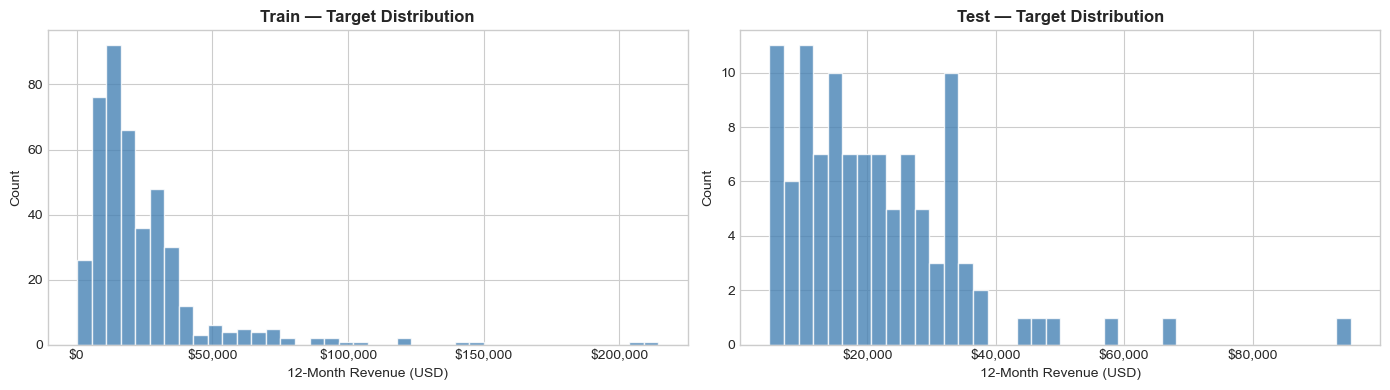

In [11]:
# Confirm no index overlap
overlap = set(X_train.index) & set(X_test.index)
print(f'Index overlap between train and test: {len(overlap)} (expected: 0)')

# Target distribution comparison
print('\n--- Target distribution ---')
dist = pd.DataFrame({
    'Train': y_train.describe(),
    'Test':  y_test.describe()
}).round(0)
print(dist)

# Visual check
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, data, label in zip(axes, [y_train, y_test], ['Train', 'Test']):
    ax.hist(data, bins=40, color='steelblue', alpha=0.8)
    ax.set_title(f'{label} — Target Distribution', fontweight='bold')
    ax.set_xlabel('12-Month Revenue (USD)')
    ax.set_ylabel('Count')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## 3. Preprocessing Pipeline

All steps in this section are fitted on `X_train` only and applied to both `X_train` and `X_test`. This prevents data leakage from the test set into any learned parameter.

### 3.1 `starting_mrr`: Median Imputation

Null values in `starting_mrr` are filled using `SimpleImputer(strategy='median')` fitted on `X_train` only. Median is preferred over mean given the right-skewed distribution of `starting_mrr` documented in EDA Section 4.2. The 36 missing rows (6.7%) are retained through imputation rather than dropped.

In [12]:
# Median imputation — fit on train only
mrr_imputer = SimpleImputer(strategy='median')
X_train['starting_mrr'] = mrr_imputer.fit_transform(X_train[['starting_mrr']]).ravel()
X_test['starting_mrr']  = mrr_imputer.transform(X_test[['starting_mrr']]).ravel()

imputed_median = mrr_imputer.statistics_[0]
print(f'\nImputed median (from train): ${imputed_median:,.2f}')
print(f'Post-imputation nulls in train: {X_train["starting_mrr"].isnull().sum()}')
print(f'Post-imputation nulls in test:  {X_test["starting_mrr"].isnull().sum()}')


Imputed median (from train): $1,299.00
Post-imputation nulls in train: 0
Post-imputation nulls in test:  0


**Observations**: The imputed median of `$1,299` means that the 36 missing rows where starting_mrr was not recorded are assigned a plan value of `$1,299`, which represents the midpoint of the observed MRR distribution in the training set. In business terms, this corresponds to a plan just above the part-time executive assistant tier - making it consistent with the notion that majority of paid inbound customers are in the small-business segment.

### 3.2 Categorical Null Encoding

Null values in `service_offering`, `cb_employees_range`, `cb_annual_revenue_ranges`, and `cb_sector` are filled with the string `'missing'`. This treats missingness as a distinct category rather than discarding rows. The EDA shows that missingness rates for firmographic fields are high enough (~19–31%) that pattern may carry predictive signal.

This step is a fixed rule with no learned parameter and is applied identically to both sets.

In [13]:
NULL_AS_MISSING_COLS = [
    'service_offering',
    'cb_employees_range',
    'cb_annual_revenue_ranges',
    'cb_sector'
]

for col in NULL_AS_MISSING_COLS:
    before_train = X_train[col].isnull().sum()
    before_test  = X_test[col].isnull().sum()
    X_train[col] = X_train[col].fillna('missing')
    X_test[col]  = X_test[col].fillna('missing')
    print(f'{col}: train nulls {before_train} → {X_train[col].isnull().sum()} | '
          f'test nulls {before_test} → {X_test[col].isnull().sum()}')

print('\nRemaining nulls in train:')
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

service_offering: train nulls 0 → 0 | test nulls 0 → 0
cb_employees_range: train nulls 132 → 0 | test nulls 31 → 0
cb_annual_revenue_ranges: train nulls 136 → 0 | test nulls 31 → 0
cb_sector: train nulls 83 → 0 | test nulls 22 → 0

Remaining nulls in train:
Series([], dtype: int64)


### 3.3 Low-Frequency Category Grouping

Categories below a minimum frequency threshold are collapsed to `'other'`. Thresholds are computed from `X_train` value counts only and applied to both sets. This prevents:
- OHE column explosion from rare categories
- Train/test vocabulary mismatch at deployment

Categories retained per feature are those with at least 10 training records.

In [14]:
GROUPING_COLS = [
    'service_offering',
    'ad_network',
    'cb_employees_range',
    'cb_annual_revenue_ranges',
    'cb_sector'
]

MIN_FREQ = 10  # minimum training records to retain a category
category_maps = {}

for col in GROUPING_COLS:
    train_counts = X_train[col].value_counts()
    keep = train_counts[train_counts >= MIN_FREQ].index.tolist()
    category_maps[col] = keep

    before_cats_train = X_train[col].nunique()
    before_cats_test  = X_test[col].nunique()

    X_train[col] = X_train[col].where(X_train[col].isin(keep), other='other')
    X_test[col]  = X_test[col].where(X_test[col].isin(keep), other='other')

    after_cats_train = X_train[col].nunique()
    after_cats_test  = X_test[col].nunique()

    print(f'\n{col}:')
    print(f'  Retained categories ({len(keep)}): {keep}')
    print(f'  Train: {before_cats_train} → {after_cats_train} unique values')
    print(f'  Test:  {before_cats_test} → {after_cats_test} unique values')
    print(f'  Train value counts after grouping:')
    print(X_train[col].value_counts().to_string())


service_offering:
  Retained categories (4): ['virtual_assistant', 'executive_assistant', 'sales', 'brand']
  Train: 7 → 5 unique values
  Test:  7 → 5 unique values
  Train value counts after grouping:
service_offering
virtual_assistant      249
executive_assistant    114
sales                   33
brand                   19
other                   12

ad_network:
  Retained categories (3): ['adwords', 'facebook', 'bing']
  Train: 5 → 4 unique values
  Test:  4 → 4 unique values
  Train value counts after grouping:
ad_network
adwords     274
facebook    139
bing         10
other         4

cb_employees_range:
  Retained categories (5): ['1-10', 'missing', '11-50', '51-250', '251-1K']
  Train: 9 → 6 unique values
  Test:  7 → 6 unique values
  Train value counts after grouping:
cb_employees_range
1-10       160
missing    132
11-50       88
51-250      28
251-1K      11
other        8

cb_annual_revenue_ranges:
  Retained categories (4): ['missing', '$0-$1M', '$1M-$10M', '$10M-$50M']


### 3.4 One-Hot Encoding

`OneHotEncoder` fitted on `X_train` categorical columns only. Key parameters:
- `drop='first'`: removes one redundant column per feature to avoid perfect multicollinearity — important for Ridge regression
- `handle_unknown='ignore'`: encodes any unseen test-set category as all-zeros rather than raising an error
- `sparse_output=False`: returns dense array for compatibility with downstream scikit-learn estimators

The resulting design matrix is used directly by tree-based models. Ridge regression additionally uses the scaled version produced in Section 3.5.

In [15]:
CAT_FEATURES = [
    'lifecycle',
    'service_offering',
    'campaign_group',
    'ad_network',
    'cb_jobtitle_type',
    'cb_employees_range',
    'cb_annual_revenue_ranges',
    'cb_sector'
]

NUM_FEATURES = ['starting_mrr']

# Verify all expected columns are present
missing_cols = [c for c in CAT_FEATURES + NUM_FEATURES if c not in X_train.columns]
if missing_cols:
    print(f'WARNING — missing columns: {missing_cols}')
else:
    print('All expected feature columns present.')

# Fit OHE on train only
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train[CAT_FEATURES])

# Transform both sets
X_train_cat = ohe.transform(X_train[CAT_FEATURES])
X_test_cat  = ohe.transform(X_test[CAT_FEATURES])

ohe_cols = ohe.get_feature_names_out(CAT_FEATURES)

# Combine with numeric features
X_train_ohe = np.hstack([X_train[NUM_FEATURES].values, X_train_cat])
X_test_ohe  = np.hstack([X_test[NUM_FEATURES].values, X_test_cat])

all_feature_names = NUM_FEATURES + list(ohe_cols)

print(f'\nPost-OHE shape — train: {X_train_ohe.shape}')
print(f'Post-OHE shape — test:  {X_test_ohe.shape}')
print(f'Total features: {len(all_feature_names)}')

# Sparsity check
sparsity = 1 - (X_train_ohe != 0).mean()
print(f'Design matrix sparsity: {sparsity:.1%}')

All expected feature columns present.

Post-OHE shape — train: (427, 31)
Post-OHE shape — test:  (107, 31)
Total features: 31
Design matrix sparsity: 80.3%


**Observations**: The post-OHE design matrix contains 31 features at 80.7% sparsity. The EDA estimated ~109 post-OHE columns based on raw category counts prior to grouping. The lower actual count reflects the low-frequency grouping step in Section 3.3, which collapsed rare categories into `other` and reduced cardinality substantially across all categorical features. This is an indication that the pipeline is working as intended. The 80.7% sparsity confirms the geometry argument from the EDA: **this sparse, high-dimensional feature space favors tree-based models over distance-based models** such as kNN, where sparsity degrades the meaningfulness of distance calculations.

### 3.5 Scaling for Linear Models

`StandardScaler` fitted on the numeric columns of `X_train` only (mean and std from training data). Applied to produce a scaled version of the full OHE design matrix for use by Ridge regression.

As tree-based models (decision tree, random forest) are invariant to feature scale, they will use the unscaled OHE output from Section 3.4 directly.

Two versions of the processed data are produced:
- `X_train_ohe` / `X_test_ohe`: unscaled. For tree-based models
- `X_train_scaled` / `X_test_scaled`: scaled. For Ridge regression

In [16]:
# Fit scaler on numeric columns of X_train only
# Numeric features are the first len(NUM_FEATURES) columns in the OHE matrix
scaler = StandardScaler()
scaler.fit(X_train_ohe[:, :len(NUM_FEATURES)])

X_train_scaled = X_train_ohe.copy()
X_test_scaled  = X_test_ohe.copy()

X_train_scaled[:, :len(NUM_FEATURES)] = scaler.transform(X_train_ohe[:, :len(NUM_FEATURES)])
X_test_scaled[:, :len(NUM_FEATURES)]  = scaler.transform(X_test_ohe[:, :len(NUM_FEATURES)])

print(f'Scaler means (numeric features): {dict(zip(NUM_FEATURES, scaler.mean_.round(4)))}')
print(f'Scaler stds  (numeric features): {dict(zip(NUM_FEATURES, scaler.scale_.round(4)))}')
print(f'\nX_train_scaled shape: {X_train_scaled.shape}')
print(f'X_test_scaled shape:  {X_test_scaled.shape}')

Scaler means (numeric features): {'starting_mrr': np.float64(2118.9928)}
Scaler stds  (numeric features): {'starting_mrr': np.float64(3252.1852)}

X_train_scaled shape: (427, 31)
X_test_scaled shape:  (107, 31)


In [17]:
# Sample comparison: unscaled vs scaled starting_mrr
sample_idx = X_train[X_train['starting_mrr'].notna()].index[:10]

comparison = pd.DataFrame({
    'starting_mrr (unscaled)': X_train_ohe[:10, 0].round(2),
    'starting_mrr (scaled)':   X_train_scaled[:10, 0].round(4),
})

print("Sample: first 10 training rows")
print(comparison.to_string(index=False))

Sample: first 10 training rows
 starting_mrr (unscaled)  starting_mrr (scaled)
               1299.0000                -0.2521
                649.5000                -0.4518
               1732.0000                -0.1190
                433.0000                -0.5184
                433.0000                -0.5184
               1732.0000                -0.1190
               1732.0000                -0.1190
               2598.0000                 0.1473
               2598.0000                 0.1473
               1039.2000                -0.3320


### 3.6 Pipeline Summary

| Feature | Transformation | Train-only fitted | EDA justification |
|---|---|---|---|
| `starting_mrr` | Median imputation | Yes (median) | 6.7% missing; right-skewed distribution favors median over mean |
| `service_offering` | Null → `missing`; low-freq → `other`; OHE `drop=first` | Yes (OHE vocabulary, grouping thresholds) | dominance of va/ea; low-freq categories unreliable |
| `cb_employees_range` | Excel artifact fix; null → `missing`; low-freq → `other`; OHE | Yes (OHE vocabulary, grouping thresholds) | Section 1.2, 4.1 — Excel corruption; 30.5% missing; non-monotonic signal |
| `cb_annual_revenue_ranges` | Null → `missing`; low-freq → `other`; OHE `drop=first` | Yes (OHE vocabulary, grouping thresholds) | Section 4.1 — 31.2% missing; non-monotonic signal |
| `cb_sector` | Null → `missing`; low-freq → `other`; OHE `drop=first` | Yes (OHE vocabulary, grouping thresholds) | Section 4.1 — 19.6% missing; low-n sectors grouped |
| `ad_network` | 4 tracking gaps derived from `channel`; low-freq → `other`; OHE `drop=first` | Yes (OHE vocabulary, grouping thresholds) | Section 4.1 — adwords/facebook dominate; twitter/linkedin low-n |
| `campaign_group` | OHE `drop=first` | Yes (OHE vocabulary) | Section 5.1 — 5 clean values; branded drives highest CLV |
| `lifecycle` | Cast to string; OHE `drop=first` | Yes (OHE vocabulary) | Section 4.1 — stored as numeric but is categorical; 89.2% lifecycle 1 |
| `cb_jobtitle_type` | OHE `drop=first` | Yes (OHE vocabulary) | Section 5.1 — weakest signal (1.46x); retained through baseline for evaluation |
| All features (linear models) | `StandardScaler` on numeric columns | Yes (mean, std) | Section 7.4 — Ridge requires scale-normalized inputs; trees do not |

## 4. Analytical Dataset Output

### 4.1 Final Dataset Shapes

In [18]:
print('--- Unscaled (tree models) ---')
print(f'X_train_ohe:  {X_train_ohe.shape}')
print(f'X_test_ohe:   {X_test_ohe.shape}')
print(f'y_train:      {y_train.shape}')
print(f'y_test:       {y_test.shape}')

print('\n--- Scaled (Ridge regression) ---')
print(f'X_train_scaled: {X_train_scaled.shape}')
print(f'X_test_scaled:  {X_test_scaled.shape}')

--- Unscaled (tree models) ---
X_train_ohe:  (427, 31)
X_test_ohe:   (107, 31)
y_train:      (427,)
y_test:       (107,)

--- Scaled (Ridge regression) ---
X_train_scaled: (427, 31)
X_test_scaled:  (107, 31)


### 4.2 Feature List

In [19]:
print(f'Total features post-OHE: {len(all_feature_names)}')
print('\nFull feature list:')
for i, feat in enumerate(all_feature_names):
    print(f'  {i+1:3d}. {feat}')

Total features post-OHE: 31

Full feature list:
    1. starting_mrr
    2. lifecycle_2
    3. lifecycle_3
    4. lifecycle_5
    5. service_offering_executive_assistant
    6. service_offering_other
    7. service_offering_sales
    8. service_offering_virtual_assistant
    9. campaign_group_core_search
   10. campaign_group_no_campaign_group
   11. campaign_group_pmax
   12. campaign_group_scaling
   13. ad_network_bing
   14. ad_network_facebook
   15. ad_network_other
   16. cb_jobtitle_type_senior leadership
   17. cb_employees_range_11-50
   18. cb_employees_range_251-1K
   19. cb_employees_range_51-250
   20. cb_employees_range_missing
   21. cb_employees_range_other
   22. cb_annual_revenue_ranges_$10M-$50M
   23. cb_annual_revenue_ranges_$1M-$10M
   24. cb_annual_revenue_ranges_missing
   25. cb_annual_revenue_ranges_other
   26. cb_sector_Financials
   27. cb_sector_Health Care
   28. cb_sector_Industrials
   29. cb_sector_Information Technology
   30. cb_sector_missing
   31.

### 4.3 Save Processed Data

In [20]:
import os
os.makedirs('../data/processed', exist_ok=True)

# Unscaled (tree models)
pd.DataFrame(X_train_ohe, columns=all_feature_names).to_csv('../data/processed/X_train.csv', index=False)
pd.DataFrame(X_test_ohe,  columns=all_feature_names).to_csv('../data/processed/X_test.csv',  index=False)

# Scaled (Ridge)
pd.DataFrame(X_train_scaled, columns=all_feature_names).to_csv('../data/processed/X_train_scaled.csv', index=False)
pd.DataFrame(X_test_scaled,  columns=all_feature_names).to_csv('../data/processed/X_test_scaled.csv',  index=False)

# Targets
y_train.reset_index(drop=True).to_csv('../data/processed/y_train.csv', index=False)
y_test.reset_index(drop=True).to_csv('../data/processed/y_test.csv',   index=False)

print('Saved to ../data/processed/:')
for f in sorted(os.listdir('../data/processed')):
    size = os.path.getsize(f'../data/processed/{f}')
    print(f'  {f}  ({size:,} bytes)')

Saved to ../data/processed/:
  X_test.csv  (14,431 bytes)
  X_test_scaled.csv  (15,862 bytes)
  X_train.csv  (55,318 bytes)
  X_train_scaled.csv  (61,018 bytes)
  y_test.csv  (1,331 bytes)
  y_train.csv  (5,181 bytes)


### 4.4 Preprocessing Notes for Modeling Notebook

This cell serves as a reference summary for `03_modeling.ipynb`.

**Dataset**
- Raw n: 535 (paid inbound) → 534 after outlier drop
- Train: ~427 rows | Test: ~107 rows (80/20 stratified split, `random_state=42`)
- Features post-OHE: 31

**Key learned parameters (train only)**
- `starting_mrr` imputed median: see Section 3.1 output
- Low-frequency grouping threshold: 10 training records minimum
- OHE vocabulary: fitted on train categories only; `handle_unknown='ignore'` for test
- Scaler: `StandardScaler` on numeric features only

**Which dataset to load per model**

| Model | Dataset |
|---|---|
| Dummy regressor | `X_train.csv` / `X_test.csv` (unscaled) |
| Ridge regression | `X_train_scaled.csv` / `X_test_scaled.csv` (scaled) |
| Decision tree | `X_train.csv` / `X_test.csv` (unscaled) |
| Random forest | `X_train.csv` / `X_test.csv` (unscaled) |

**Evaluation**
- Primary metric: MAE (reported in USD)
- Secondary metric: RMSE (reported alongside MAE)
- Robustness metric: Median AE (Right-skewed target pulls MAE upward; Median AE characterizes typical error without tail distortion)
- Both raw target and `log1p`-transformed target variants to be evaluated
- Cross-validation used throughout given n~427 training rows